In [7]:
from pathlib import Path

print("Notebook working directory:")
print(Path.cwd())

Notebook working directory:
c:\Users\pc\diabetes-readmission-ml\notebooks


In [8]:
from pathlib import Path
import urllib.request
import zipfile

import pandas as pd

In [9]:
# Project root and data paths

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
DATASET_FILE = DATA_DIR / "diabetes_130_us_hospitals.zip"
DATA_FILE = DATA_DIR / "diabetic_data.csv"
MAPPING_FILE = DATA_DIR / "IDS_mapping.csv"

print("Project root:")
print(PROJECT_ROOT)

print("\nData directory:")
print(DATA_DIR)

print("\nFiles:")
print("Archive:", DATASET_FILE)
print("Dataset:", DATA_FILE)
print("Mapping:", MAPPING_FILE)

Project root:
c:\Users\pc\diabetes-readmission-ml

Data directory:
c:\Users\pc\diabetes-readmission-ml\data\raw

Files:
Archive: c:\Users\pc\diabetes-readmission-ml\data\raw\diabetes_130_us_hospitals.zip
Dataset: c:\Users\pc\diabetes-readmission-ml\data\raw\diabetic_data.csv
Mapping: c:\Users\pc\diabetes-readmission-ml\data\raw\IDS_mapping.csv


In [10]:
# Verify the dataset files

print("Archive exists:", DATASET_FILE.exists())
print("Dataset exists:", DATA_FILE.exists())
print("Mapping file exists:", MAPPING_FILE.exists())

Archive exists: True
Dataset exists: True
Mapping file exists: True


In [11]:
# Inspect files contained in the UCI archive

with zipfile.ZipFile(DATASET_FILE, "r") as archive:
    print("Files contained in the UCI archive:\n")

    for file_name in archive.namelist():
        print(file_name)

Files contained in the UCI archive:

diabetic_data.csv
IDS_mapping.csv


In [12]:
# Preview the ID mapping file

with zipfile.ZipFile(DATASET_FILE, "r") as archive:
    with archive.open("IDS_mapping.csv") as mapping_file:
        mapping_preview = mapping_file.read(3000).decode("utf-8")

print(mapping_preview)

admission_type_id,description
1,Emergency
2,Urgent
3,Elective
4,Newborn
5,Not Available
6,NULL
7,Trauma Center
8,Not Mapped
,
discharge_disposition_id,description
1,Discharged to home
2,Discharged/transferred to another short term hospital
3,Discharged/transferred to SNF
4,Discharged/transferred to ICF
5,Discharged/transferred to another type of inpatient care institution
6,Discharged/transferred to home with home health service
7,Left AMA
8,Discharged/transferred to home under care of Home IV provider
9,Admitted as an inpatient to this hospital
10,Neonate discharged to another hospital for neonatal aftercare
11,Expired
12,Still patient or expected to return for outpatient services
13,Hospice / home
14,Hospice / medical facility
15,Discharged/transferred within this institution to Medicare approved swing bed
16,Discharged/transferred/referred another institution for outpatient services
17,Discharged/transferred/referred to this institution for outpatient services
18,NULL
19,"Expired at

In [13]:
# Load the raw patient-level dataset

data = pd.read_csv(DATA_FILE)

print("Dataset shape:")
print(data.shape)

print("\nColumn names:")
for column_number, column_name in enumerate(data.columns, start=1):
    print(f"{column_number:02d}. {column_name}")

print("\nFirst five rows:")
display(
    data.head().T
)

print('\nData Info:')
data.info()

Dataset shape:
(101766, 50)

Column names:
01. encounter_id
02. patient_nbr
03. race
04. gender
05. age
06. weight
07. admission_type_id
08. discharge_disposition_id
09. admission_source_id
10. time_in_hospital
11. payer_code
12. medical_specialty
13. num_lab_procedures
14. num_procedures
15. num_medications
16. number_outpatient
17. number_emergency
18. number_inpatient
19. diag_1
20. diag_2
21. diag_3
22. number_diagnoses
23. max_glu_serum
24. A1Cresult
25. metformin
26. repaglinide
27. nateglinide
28. chlorpropamide
29. glimepiride
30. acetohexamide
31. glipizide
32. glyburide
33. tolbutamide
34. pioglitazone
35. rosiglitazone
36. acarbose
37. miglitol
38. troglitazone
39. tolazamide
40. examide
41. citoglipton
42. insulin
43. glyburide-metformin
44. glipizide-metformin
45. glimepiride-pioglitazone
46. metformin-rosiglitazone
47. metformin-pioglitazone
48. change
49. diabetesMed
50. readmitted

First five rows:


,0,1,2,3,4
encounter_id,2278392,149190,64410,500364,16680
patient_nbr,8222157,55629189,86047875,82442376,42519267
race,Caucasian,Caucasian,AfricanAmerican,Caucasian,Caucasian
gender,Female,Female,Female,Male,Male
age,[0-10),[10-20),[20-30),[30-40),[40-50)
weight,?,?,?,?,?
admission_type_id,6,1,1,1,1
discharge_disposition_id,25,1,1,1,1
admission_source_id,1,7,7,7,7
time_in_hospital,1,3,2,2,1



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications    

In [14]:
# Create the 30-day readmission target

data["readmitted_30d"] = (
    data["readmitted"] == "<30"
).astype(int)

print("Target definition:")
print("1 = readmitted within 30 days (<30)")
print("0 = not readmitted within 30 days (NO or >30)")

Target definition:
1 = readmitted within 30 days (<30)
0 = not readmitted within 30 days (NO or >30)


In [15]:
# Inspect the 30-day readmission distribution

print("30-day readmission counts:")
print(data["readmitted_30d"].value_counts())

print("\n30-day readmission proportions:")
print(data["readmitted_30d"].value_counts(normalize=True))

30-day readmission counts:
readmitted_30d
0    90409
1    11357
Name: count, dtype: int64

30-day readmission proportions:
readmitted_30d
0    0.888401
1    0.111599
Name: proportion, dtype: float64


In [16]:
# Verify target values

print("Unique target values:")
print(sorted(data["readmitted_30d"].unique()))

Unique target values:
[np.int64(0), np.int64(1)]


In [17]:
# Missing-value analysis

question_mark_counts = (data == "?").sum()
nan_counts = data.isna().sum()

missing_counts = question_mark_counts + nan_counts
missing_percentages = missing_counts / len(data) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_percentages,
})

missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values(
        "missing_percentage",
        ascending=False,
    )
)

display(missing_summary)

,missing_count,missing_percentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


In [18]:
# Identify numeric and categorical columns

numeric_columns = (
    data.select_dtypes(include="number").columns.tolist()
)

categorical_columns = (
    data.select_dtypes(exclude="number").columns.tolist()
)

print("Numeric columns:")
print(numeric_columns)

print("\nCategorical/string columns:")
print(categorical_columns)

Numeric columns:
['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'readmitted_30d']

Categorical/string columns:
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [19]:
# Unique-value count for every column

unique_summary = (
    data.nunique(dropna=False)
    .sort_values(ascending=False)
)

display(unique_summary)

encounter_id                101766
patient_nbr                  71518
diag_3                         790
diag_2                         749
diag_1                         717
num_lab_procedures             118
num_medications                 75
medical_specialty               73
number_outpatient               39
number_emergency                33
discharge_disposition_id        26
number_inpatient                21
payer_code                      18
admission_source_id             17
number_diagnoses                16
time_in_hospital                14
age                             10
weight                          10
admission_type_id                8
num_procedures                   7
race                             6
insulin                          4
max_glu_serum                    4
A1Cresult                        4
metformin                        4
repaglinide                      4
nateglinide                      4
chlorpropamide                   4
glimepiride         

In [20]:
# Analyze patient identifiers and repeated encounters

print("Identifier analysis:\n")

for column in ["encounter_id", "patient_nbr"]:
    print(
        f"{column}: "
        f"{data[column].nunique():,} unique values "
        f"out of {len(data):,} rows"
    )

patient_encounter_counts = data["patient_nbr"].value_counts()

print("\nEncounter-count distribution per patient:")
display(
    patient_encounter_counts
    .value_counts()
    .sort_index()
)

multiple_encounter_patients = (
    patient_encounter_counts > 1
).sum()

multiple_encounter_percentage = (
    patient_encounter_counts > 1
).mean()

print(
    f"\nPatients with multiple encounters: "
    f"{multiple_encounter_patients:,}"
)

print(
    f"Percentage of patients with multiple encounters: "
    f"{multiple_encounter_percentage:.2%}"
)

Identifier analysis:

encounter_id: 101,766 unique values out of 101,766 rows
patient_nbr: 71,518 unique values out of 101,766 rows

Encounter-count distribution per patient:


count
1     54745
2     10434
3      3328
4      1421
5       717
6       346
7       207
8       111
9        70
10       42
11       20
12       19
13       14
14        5
15        9
16        4
17        3
18        6
19        3
20        6
21        1
22        2
23        3
28        1
40        1
Name: count, dtype: int64


Patients with multiple encounters: 16,773
Percentage of patients with multiple encounters: 23.45%


In [21]:
unique_counts = data.nunique(dropna=False).sort_values()

constant_columns = unique_counts[unique_counts == 1]

print("Constant columns:")
display(constant_columns)

print("\nNumber of constant columns:", len(constant_columns))

Constant columns:


citoglipton    1
examide        1
dtype: int64


Number of constant columns: 2


In [22]:
patient_summary = (
    data.groupby("patient_nbr")
    .agg(
        number_of_encounters=("encounter_id", "size"),
        readmission_rate_30d=("readmitted_30d", "mean")
    )
)

patient_summary["patient_group"] = patient_summary[
    "number_of_encounters"
].apply(
    lambda x: "One encounter only"
    if x == 1
    else "Multiple encounters"
)

summary_table = (
    patient_summary
    .groupby("patient_group")
    .agg(
        patients=("number_of_encounters", "size"),
        avg_encounters_per_patient=("number_of_encounters", "mean"),
        readmission_rate_30d=("readmission_rate_30d", "mean")
    )
    .reindex(["One encounter only", "Multiple encounters"])
    .reset_index()
)

summary_table["avg_encounters_per_patient"] = (
    summary_table["avg_encounters_per_patient"].round(2)
)

summary_table["readmission_rate_30d"] = (
    summary_table["readmission_rate_30d"] * 100
).round(2).astype(str) + "%"

summary_table.columns = [
    "Patient group",
    "Patients",
    "Avg. encounters per patient",
    "30-day readmission rate"
]

display(summary_table)

,Patient group,Patients,Avg. encounters per patient,30-day readmission rate
0,One encounter only,54745,1.0,3.96%
1,Multiple encounters,16773,2.8,17.41%


In [23]:
duplicate_encounters = data["encounter_id"].duplicated().sum()

print(f"Duplicate encounter_id values: {duplicate_encounters:,}")

Duplicate encounter_id values: 0


In [24]:
# Identify categorical columns
categorical_columns = [
    column
    for column in data.columns
    if data[column].dtype == "str"
]

print(f"Number of categorical columns: {len(categorical_columns)}")

print("\nCategorical columns:")
for column in categorical_columns:
    print(f"- {column}")

# Inspect the most frequent values
for column in categorical_columns:
    print("\n" + "=" * 70)
    print(f"Column: {column}")
    print("=" * 70)

    value_counts = (
        data[column]
        .value_counts(dropna=False)
        .head(15)
    )

    display(value_counts)

Number of categorical columns: 37

Categorical columns:
- race
- gender
- age
- weight
- payer_code
- medical_specialty
- diag_1
- diag_2
- diag_3
- max_glu_serum
- A1Cresult
- metformin
- repaglinide
- nateglinide
- chlorpropamide
- glimepiride
- acetohexamide
- glipizide
- glyburide
- tolbutamide
- pioglitazone
- rosiglitazone
- acarbose
- miglitol
- troglitazone
- tolazamide
- examide
- citoglipton
- insulin
- glyburide-metformin
- glipizide-metformin
- glimepiride-pioglitazone
- metformin-rosiglitazone
- metformin-pioglitazone
- change
- diabetesMed
- readmitted

Column: race


race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


Column: gender


gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


Column: age


...

change
No    54755
Ch    47011
Name: count, dtype: int64


Column: diabetesMed


diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64


Column: readmitted


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [25]:
# Inspect numerical variables

numeric_columns = [
    column
    for column in data.columns
    if data[column].dtype == "int64"
]

print(f"Number of numerical columns: {len(numeric_columns)}")

print("\nNumerical columns:")
for column in numeric_columns:
    print(f"- {column}")

print("\nNumerical variable summary:")
display(
    data[numeric_columns].describe().T
)

Number of numerical columns: 14

Numerical columns:
- encounter_id
- patient_nbr
- admission_type_id
- discharge_disposition_id
- admission_source_id
- time_in_hospital
- num_lab_procedures
- num_procedures
- num_medications
- number_outpatient
- number_emergency
- number_inpatient
- number_diagnoses
- readmitted_30d

Numerical variable summary:


,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


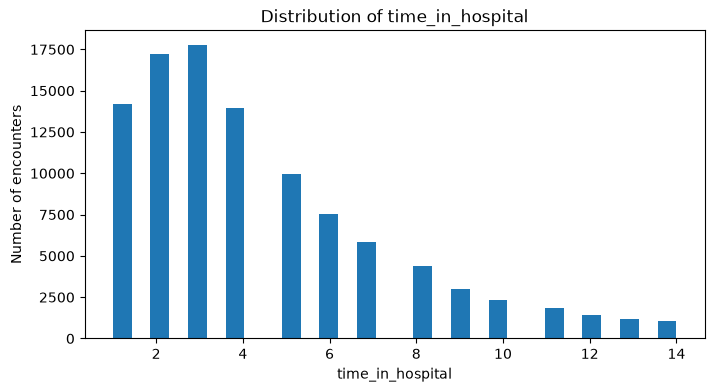

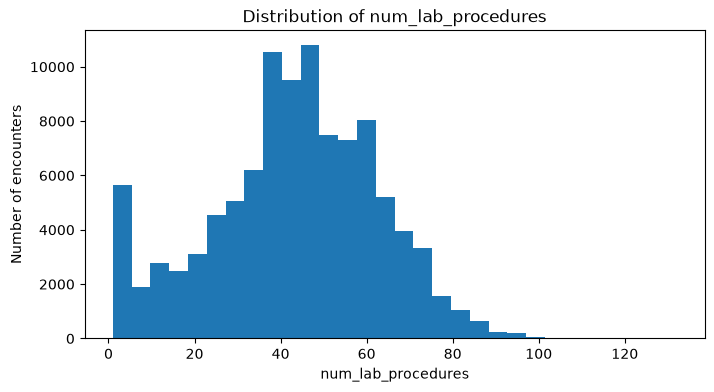

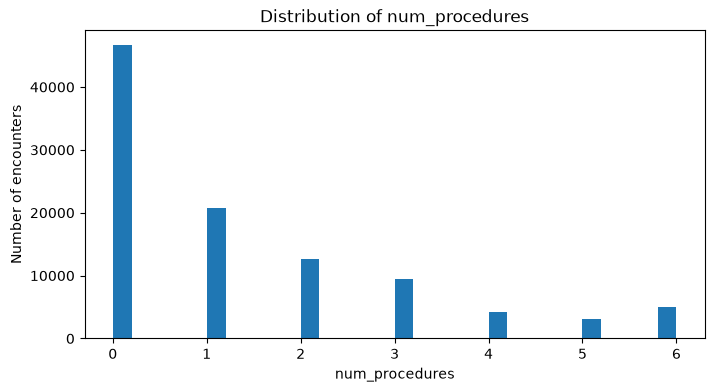

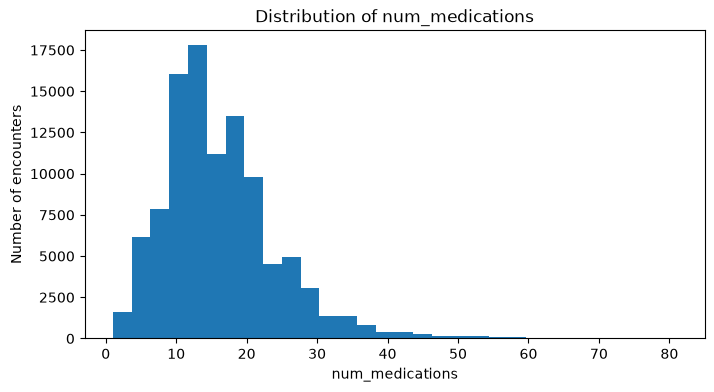

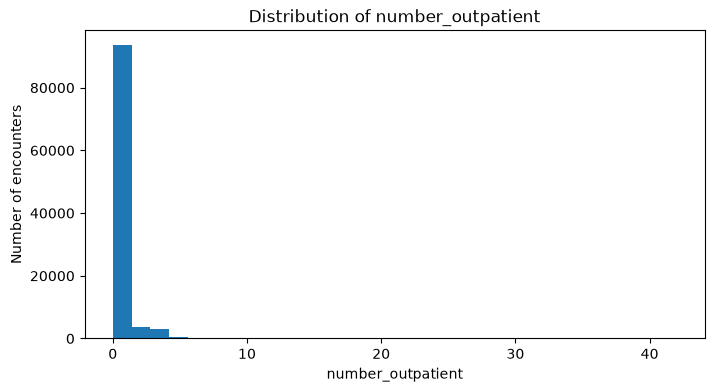

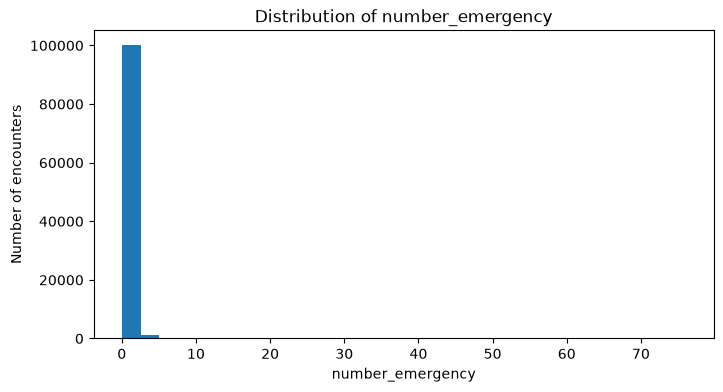

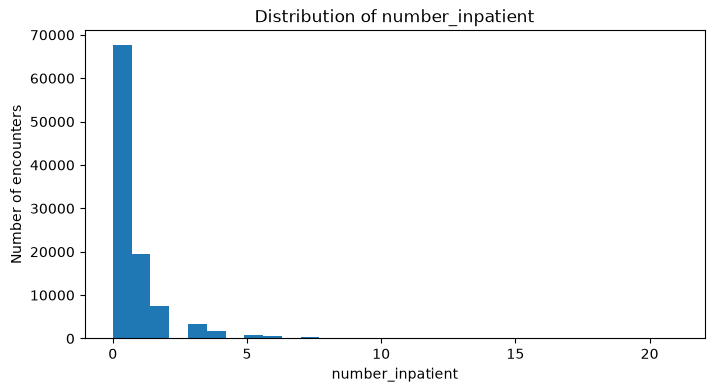

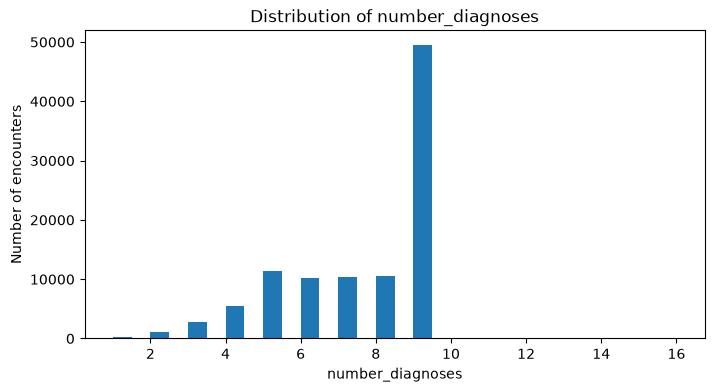

In [26]:
import matplotlib.pyplot as plt

count_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

for column in count_columns:
    plt.figure(figsize=(8, 4))
    plt.hist(data[column], bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of encounters")
    plt.show()

In [27]:
# Identify potential outliers using the IQR rule

count_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

outlier_summary = []

for column in count_columns:
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "column": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percentage": (
            outlier_count / len(data) * 100
        )
    })

outlier_summary = pd.DataFrame(outlier_summary)

# Round values for easier reading
outlier_summary = outlier_summary.round({
    "Q1": 2,
    "Q3": 2,
    "IQR": 2,
    "lower_bound": 2,
    "upper_bound": 2,
    "outlier_percentage": 2
})

display(outlier_summary)

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,time_in_hospital,2.0,6.0,4.0,-4.0,12.0,2252,2.21
1,num_lab_procedures,31.0,57.0,26.0,-8.0,96.0,143,0.14
2,num_procedures,0.0,2.0,2.0,-3.0,5.0,4954,4.87
3,num_medications,10.0,20.0,10.0,-5.0,35.0,2557,2.51
4,number_outpatient,0.0,0.0,0.0,0.0,0.0,16739,16.45
5,number_emergency,0.0,0.0,0.0,0.0,0.0,11383,11.19
6,number_inpatient,0.0,1.0,1.0,-1.5,2.5,7049,6.93
7,number_diagnoses,6.0,9.0,3.0,1.5,13.5,281,0.28


In [28]:
skewed_columns = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "num_medications"
]

for column in skewed_columns:
    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)

    display(
        data[column]
        .value_counts()
        .sort_index()
        .tail(15)
    )


number_outpatient


number_outpatient
24    3
25    2
26    2
27    3
28    1
29    2
33    2
34    1
35    2
36    2
37    1
38    1
39    1
40    1
42    1
Name: count, dtype: int64


number_emergency


number_emergency
19    4
20    4
21    2
22    6
24    1
25    2
28    1
29    1
37    1
42    1
46    1
54    1
63    1
64    1
76    1
Name: count, dtype: int64


number_inpatient


number_inpatient
6     480
7     268
8     151
9     111
10     61
11     49
12     34
13     20
14     10
15      9
16      6
17      1
18      1
19      2
21      1
Name: count, dtype: int64


num_medications


num_medications
61    14
62    15
63    14
64     8
65    12
66     5
67     7
68     7
69     5
70     2
72     3
74     1
75     2
79     1
81     1
Name: count, dtype: int64

In [29]:
readmission_by_los = (
    data.groupby("time_in_hospital")["readmitted_30d"]
    .agg(
        encounters="count",
        readmissions_30d="sum",
        readmission_rate="mean"
    )
    .reset_index()
)

readmission_by_los["readmission_rate"] = (
    readmission_by_los["readmission_rate"] * 100
).round(2)

display(readmission_by_los)

,time_in_hospital,encounters,readmissions_30d,readmission_rate
0,1,14208,1162,8.18
1,2,17224,1712,9.94
2,3,17756,1894,10.67
3,4,13924,1644,11.81
4,5,9966,1199,12.03
5,6,7539,949,12.59
6,7,5859,752,12.83
7,8,4391,625,14.23
8,9,3002,412,13.72
9,10,2342,336,14.35


In [30]:
readmission_by_previous_inpatient = (
    data.groupby("number_inpatient")["readmitted_30d"]
    .agg(
        encounters="count",
        readmissions_30d="sum",
        readmission_rate="mean"
    )
    .reset_index()
)

readmission_by_previous_inpatient["readmission_rate"] = (
    readmission_by_previous_inpatient["readmission_rate"] * 100
).round(2)

display(readmission_by_previous_inpatient)

,number_inpatient,encounters,readmissions_30d,readmission_rate
0,0,67630,5706,8.44
1,1,19521,2523,12.92
2,2,7566,1319,17.43
3,3,3411,692,20.29
4,4,1622,383,23.61
5,5,812,255,31.40
6,6,480,166,34.58
7,7,268,95,35.45
8,8,151,67,44.37
9,9,111,47,42.34


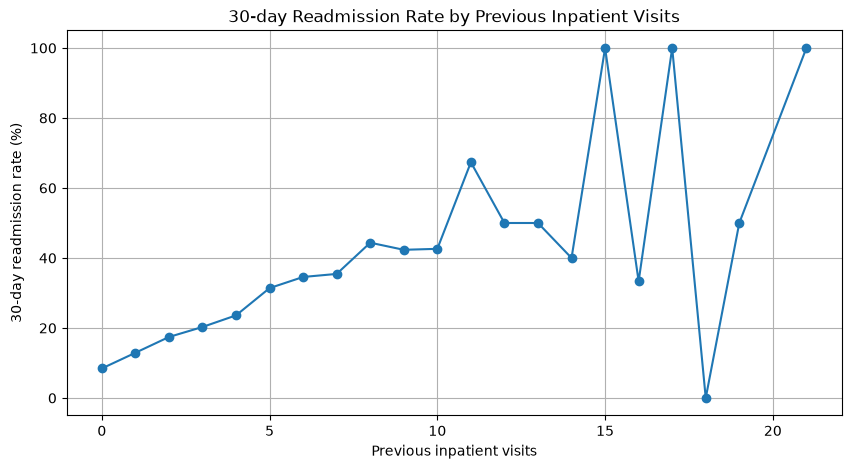

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    readmission_by_previous_inpatient["number_inpatient"],
    readmission_by_previous_inpatient["readmission_rate"],
    marker="o"
)

plt.xlabel("Previous inpatient visits")
plt.ylabel("30-day readmission rate (%)")
plt.title("30-day Readmission Rate by Previous Inpatient Visits")
plt.grid(True)
plt.show()

In [32]:
readmission_by_previous_inpatient[
    ["number_inpatient", "encounters", "readmission_rate"]
]

,number_inpatient,encounters,readmission_rate
0,0,67630,8.44
1,1,19521,12.92
2,2,7566,17.43
3,3,3411,20.29
4,4,1622,23.61
5,5,812,31.40
6,6,480,34.58
7,7,268,35.45
8,8,151,44.37
9,9,111,42.34


In [33]:
readmission_by_previous_outpatient = (
    data.groupby("number_outpatient")["readmitted_30d"]
    .agg(
        encounters="count",
        readmissions_30d="sum",
        readmission_rate="mean"
    )
    .reset_index()
)

readmission_by_previous_outpatient["readmission_rate"] = (
    readmission_by_previous_outpatient["readmission_rate"] * 100
).round(2)

display(readmission_by_previous_outpatient)

,number_outpatient,encounters,readmissions_30d,readmission_rate
0,0,85027,9076,10.67
1,1,8547,1190,13.92
2,2,3594,494,13.75
3,3,2042,251,12.29
4,4,1099,166,15.10
5,5,533,63,11.82
6,6,303,40,13.20
7,7,155,24,15.48
8,8,98,5,5.10
9,9,83,13,15.66


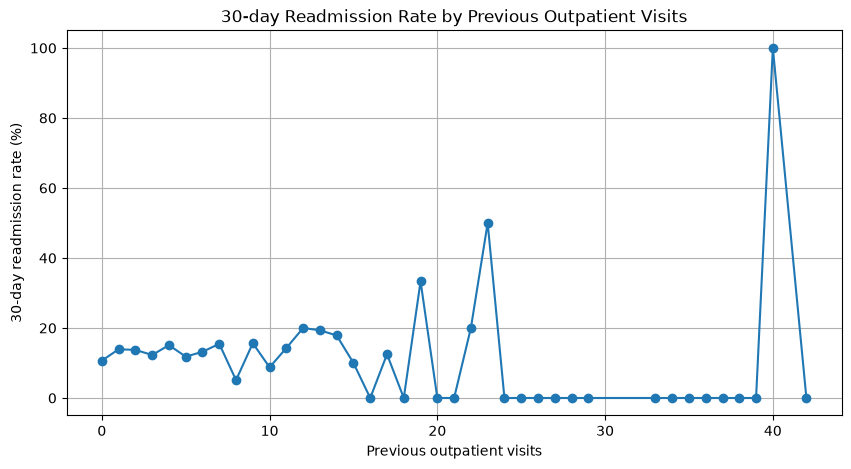

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    readmission_by_previous_outpatient["number_outpatient"],
    readmission_by_previous_outpatient["readmission_rate"],
    marker="o"
)

plt.xlabel("Previous outpatient visits")
plt.ylabel("30-day readmission rate (%)")
plt.title("30-day Readmission Rate by Previous Outpatient Visits")
plt.grid(True)
plt.show()

In [35]:
readmission_by_previous_emergency = (
    data.groupby("number_emergency")["readmitted_30d"]
    .agg(
        encounters="count",
        readmissions_30d="sum",
        readmission_rate="mean"
    )
    .reset_index()
)

readmission_by_previous_emergency["readmission_rate"] = (
    readmission_by_previous_emergency["readmission_rate"] * 100
).round(2)

display(readmission_by_previous_emergency)

,number_emergency,encounters,readmissions_30d,readmission_rate
0,0,90383,9467,10.47
1,1,7677,1102,14.35
2,2,2042,373,18.27
3,3,725,147,20.28
4,4,374,115,30.75
5,5,192,47,24.48
6,6,94,22,23.40
7,7,73,19,26.03
8,8,50,16,32.00
9,9,33,12,36.36


In [36]:
data["number_emergency"].value_counts().sort_index()

number_emergency
0     90383
1      7677
2      2042
3       725
4       374
5       192
6        94
7        73
8        50
9        33
10       34
11       23
12       10
13       12
14        3
15        3
16        5
18        5
19        4
20        4
21        2
22        6
24        1
25        2
28        1
29        1
37        1
42        1
46        1
54        1
63        1
64        1
76        1
Name: count, dtype: int64

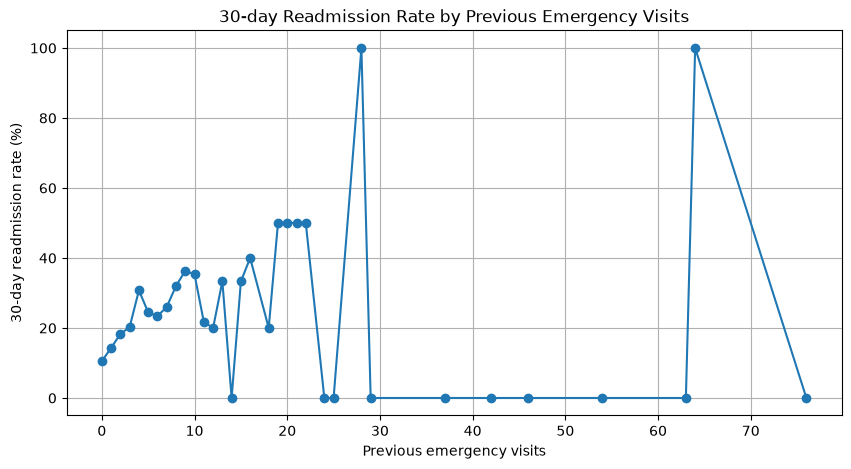

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    readmission_by_previous_emergency["number_emergency"],
    readmission_by_previous_emergency["readmission_rate"],
    marker="o"
)

plt.xlabel("Previous emergency visits")
plt.ylabel("30-day readmission rate (%)")
plt.title("30-day Readmission Rate by Previous Emergency Visits")
plt.grid(True)
plt.show()

In [38]:
readmission_by_age = (
    data.groupby("age")["readmitted_30d"]
    .agg(
        encounters="count",
        readmissions_30d="sum",
        readmission_rate="mean"
    )
    .reset_index()
)

age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

readmission_by_age["age"] = pd.Categorical(
    readmission_by_age["age"],
    categories=age_order,
    ordered=True
)

readmission_by_age = readmission_by_age.sort_values("age")

readmission_by_age["readmission_rate"] = (
    readmission_by_age["readmission_rate"] * 100
).round(2)

display(readmission_by_age)

,age,encounters,readmissions_30d,readmission_rate
0,[0-10),161,3,1.86
1,[10-20),691,40,5.79
2,[20-30),1657,236,14.24
3,[30-40),3775,424,11.23
4,[40-50),9685,1027,10.60
5,[50-60),17256,1668,9.67
6,[60-70),22483,2502,11.13
7,[70-80),26068,3069,11.77
8,[80-90),17197,2078,12.08
9,[90-100),2793,310,11.10


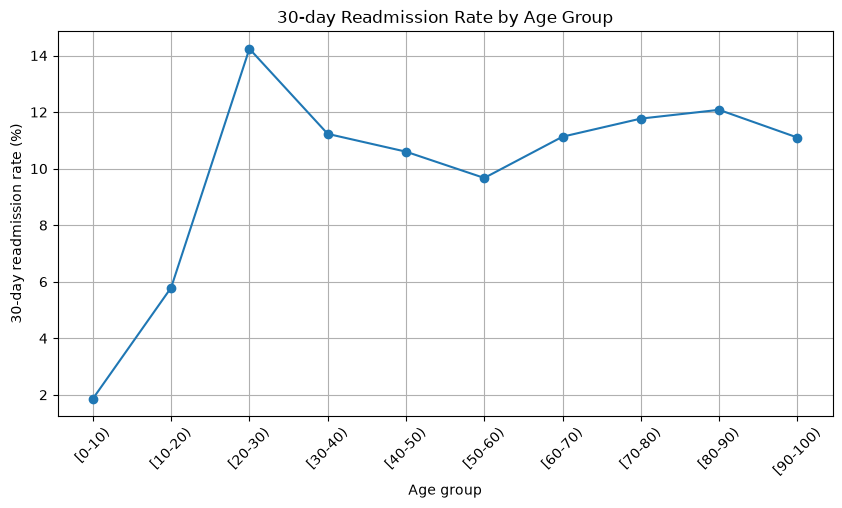

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    readmission_by_age["age"].astype(str),
    readmission_by_age["readmission_rate"],
    marker="o"
)

plt.xlabel("Age group")
plt.ylabel("30-day readmission rate (%)")
plt.title("30-day Readmission Rate by Age Group")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [40]:
readmission_by_gender = (
    data.groupby("gender")["readmitted_30d"]
    .agg(
        encounters="count",
        readmissions_30d="sum",
        readmission_rate="mean"
    )
    .reset_index()
)

readmission_by_gender["readmission_rate"] = (
    readmission_by_gender["readmission_rate"] * 100
).round(2)

display(readmission_by_gender)

,gender,encounters,readmissions_30d,readmission_rate
0,Female,54708,6152,11.25
1,Male,47055,5205,11.06
2,Unknown/Invalid,3,0,0.00


In [41]:
readmission_by_race = (
    data.groupby("race")["readmitted_30d"]
    .agg(
        encounters="count",
        readmissions_30d="sum",
        readmission_rate="mean"
    )
    .reset_index()
)

readmission_by_race["readmission_rate"] = (
    readmission_by_race["readmission_rate"] * 100
).round(2)

display(readmission_by_race)

,race,encounters,readmissions_30d,readmission_rate
0,?,2273,188,8.27
1,AfricanAmerican,19210,2155,11.22
2,Asian,641,65,10.14
3,Caucasian,76099,8592,11.29
4,Hispanic,2037,212,10.41
5,Other,1506,145,9.63


In [42]:
mapping = pd.read_csv(MAPPING_FILE)

display(mapping)

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
...,...,...
62,22,Transfer from hospital inpt/same fac reslt in...
63,23,Born inside this hospital
64,24,Born outside this hospital
65,25,Transfer from Ambulatory Surgery Center


In [43]:
print("Shape:", mapping.shape)
print("\nColumns:")
print(mapping.columns.tolist())

print("\nFirst 15 rows:")
display(mapping.head(15))

print("\nLast 15 rows:")
display(mapping.tail(15))

Shape: (67, 2)

Columns:
['admission_type_id', 'description']

First 15 rows:


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description



Last 15 rows:


,admission_type_id,description
52,11,Normal Delivery
53,12,Premature Delivery
54,13,Sick Baby
55,14,Extramural Birth
56,15,Not Available
57,17,NaN
58,18,Transfer From Another Home Health Agency
59,19,Readmission to Same Home Health Agency
60,20,Not Mapped
61,21,Unknown/Invalid


In [44]:
for index, row in mapping.iterrows():
    if pd.isna(row["admission_type_id"]) and pd.isna(row["description"]):
        print(f"Blank row: {index}")
    elif str(row["admission_type_id"]).endswith("_id"):
        print(f"Section header at row {index}: {row['admission_type_id']}")

Blank row: 8
Section header at row 9: discharge_disposition_id
Blank row: 40
Section header at row 41: admission_source_id


In [45]:
admission_type_mapping = mapping.iloc[0:8].copy()

discharge_disposition_mapping = mapping.iloc[10:40].copy()
discharge_disposition_mapping.columns = [
    "discharge_disposition_id",
    "description"
]

admission_source_mapping = mapping.iloc[42:67].copy()
admission_source_mapping.columns = [
    "admission_source_id",
    "description"
]

print("Admission type mapping:")
display(admission_type_mapping)

print("Discharge disposition mapping:")
display(discharge_disposition_mapping)

print("Admission source mapping:")
display(admission_source_mapping)

Admission type mapping:


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped


Discharge disposition mapping:


,discharge_disposition_id,description
10,1,Discharged to home
11,2,Discharged/transferred to another short term h...
12,3,Discharged/transferred to SNF
13,4,Discharged/transferred to ICF
14,5,Discharged/transferred to another type of inpa...
15,6,Discharged/transferred to home with home healt...
16,7,Left AMA
17,8,Discharged/transferred to home under care of H...
18,9,Admitted as an inpatient to this hospital
19,10,Neonate discharged to another hospital for neo...


Admission source mapping:


,admission_source_id,description
42,1,Physician Referral
43,2,Clinic Referral
44,3,HMO Referral
45,4,Transfer from a hospital
46,5,Transfer from a Skilled Nursing Facility (SNF)
47,6,Transfer from another health care facility
48,7,Emergency Room
49,8,Court/Law Enforcement
50,9,Not Available
51,10,Transfer from critial access hospital


In [46]:
# Check whether every ID in the dataset exists in its mapping
for column_name, mapping_df in [
    ("admission_type_id", admission_type_mapping),
    ("discharge_disposition_id", discharge_disposition_mapping),
    ("admission_source_id", admission_source_mapping),
]:
    # Get IDs actually used in the dataset
    data_ids = set(data[column_name].unique())

    # Get valid IDs from the mapping table
    mapping_ids = set(mapping_df[column_name].dropna())

    # Find dataset IDs that have no mapping
    missing_from_mapping = sorted(data_ids - mapping_ids)

    print(f"\n{column_name}")
    print(f"Unique IDs in data: {len(data_ids)}")
    print(f"IDs in mapping: {len(mapping_ids)}")
    print(f"IDs in data without mapping: {missing_from_mapping}")


admission_type_id
Unique IDs in data: 8
IDs in mapping: 8
IDs in data without mapping: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

discharge_disposition_id
Unique IDs in data: 26
IDs in mapping: 30
IDs in data without mapping: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(27), np.int64(28)]

admission_source_id
Unique IDs in data: 17
IDs in mapping: 25
IDs in data without mapping: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(17), np.int64(20), np.int64(22), np.int64(25)]


In [47]:
# Check the ID data types in each mapping
for name, mapping_df, column in [
    ("Admission type", admission_type_mapping, "admission_type_id"),
    ("Discharge disposition", discharge_disposition_mapping, "discharge_disposition_id"),
    ("Admission source", admission_source_mapping, "admission_source_id"),
]:
    print(f"\n{name}")
    print(mapping_df[column].tolist())
    print("Data type:", mapping_df[column].dtype)


Admission type
['1', '2', '3', '4', '5', '6', '7', '8']
Data type: str

Discharge disposition
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '30', '27', '28', '29']
Data type: str

Admission source
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26']
Data type: str


In [48]:
# Convert mapping IDs from strings to integers
for mapping_df, column_name in [
    (admission_type_mapping, "admission_type_id"),
    (discharge_disposition_mapping, "discharge_disposition_id"),
    (admission_source_mapping, "admission_source_id"),
]:
    mapping_df[column_name] = mapping_df[column_name].astype(int)

# Confirm the conversion
print(admission_type_mapping.dtypes)
print(discharge_disposition_mapping.dtypes)
print(admission_source_mapping.dtypes)

admission_type_id    int64
description            str
dtype: object
discharge_disposition_id    int64
description                   str
dtype: object
admission_source_id    int64
description              str
dtype: object


In [49]:
# Check that all dataset IDs have a mapping
for column_name, mapping_df in [
    ("admission_type_id", admission_type_mapping),
    ("discharge_disposition_id", discharge_disposition_mapping),
    ("admission_source_id", admission_source_mapping),
]:
    # IDs used in the dataset
    data_ids = set(data[column_name].unique())

    # IDs available in the mapping
    mapping_ids = set(mapping_df[column_name])

    # Dataset IDs without a mapping
    missing_from_mapping = sorted(data_ids - mapping_ids)

    print(f"\n{column_name}")
    print(f"Unique IDs in data: {len(data_ids)}")
    print(f"IDs in mapping: {len(mapping_ids)}")
    print(f"IDs in data without mapping: {missing_from_mapping}")


admission_type_id
Unique IDs in data: 8
IDs in mapping: 8
IDs in data without mapping: []

discharge_disposition_id
Unique IDs in data: 26
IDs in mapping: 30
IDs in data without mapping: []

admission_source_id
Unique IDs in data: 17
IDs in mapping: 25
IDs in data without mapping: []


In [50]:
# Create ID-to-description lookup dictionaries
admission_type_lookup = dict(
    zip(admission_type_mapping["admission_type_id"],
        admission_type_mapping["description"])
)

discharge_disposition_lookup = dict(
    zip(discharge_disposition_mapping["discharge_disposition_id"],
        discharge_disposition_mapping["description"])
)

admission_source_lookup = dict(
    zip(admission_source_mapping["admission_source_id"],
        admission_source_mapping["description"])
)

# Add readable versions while keeping the original ID columns
data["admission_type"] = data["admission_type_id"].map(admission_type_lookup)
data["discharge_disposition"] = data["discharge_disposition_id"].map(
    discharge_disposition_lookup
)
data["admission_source"] = data["admission_source_id"].map(
    admission_source_lookup
)

# Verify the new columns
display(
    data[
        [
            "admission_type_id",
            "admission_type",
            "discharge_disposition_id",
            "discharge_disposition",
            "admission_source_id",
            "admission_source",
        ]
    ].head(10)
)

,admission_type_id,admission_type,discharge_disposition_id,discharge_disposition,admission_source_id,admission_source
0,6,NaN,25,Not Mapped,1,Physician Referral
1,1,Emergency,1,Discharged to home,7,Emergency Room
2,1,Emergency,1,Discharged to home,7,Emergency Room
3,1,Emergency,1,Discharged to home,7,Emergency Room
4,1,Emergency,1,Discharged to home,7,Emergency Room
5,2,Urgent,1,Discharged to home,2,Clinic Referral
6,3,Elective,1,Discharged to home,2,Clinic Referral
7,1,Emergency,1,Discharged to home,7,Emergency Room
8,2,Urgent,1,Discharged to home,4,Transfer from a hospital
9,3,Elective,3,Discharged/transferred to SNF,4,Transfer from a hospital


In [51]:
# Count observations for each decoded category
for column_name in [
    "admission_type",
    "discharge_disposition",
    "admission_source",
]:
    print(f"\n{column_name}")
    
    category_counts = (
        data[column_name]
        .value_counts(dropna=False)
        .rename_axis(column_name)
        .reset_index(name="encounters")
    )
    
    display(category_counts)


admission_type


,admission_type,encounters
0,Emergency,53990
1,Elective,18869
2,Urgent,18480
3,NaN,5291
4,Not Available,4785
5,Not Mapped,320
6,Trauma Center,21
7,Newborn,10



discharge_disposition


,discharge_disposition,encounters
0,Discharged to home,60234
1,Discharged/transferred to SNF,13954
2,Discharged/transferred to home with home healt...,12902
3,NaN,3691
4,Discharged/transferred to another short term h...,2128
5,Discharged/transferred to another rehab fac in...,1993
6,Expired,1642
7,Discharged/transferred to another type of inpa...,1184
8,Not Mapped,989
9,Discharged/transferred to ICF,815



admission_source


,admission_source,encounters
0,Emergency Room,57494
1,Physician Referral,29565
2,NaN,6781
3,Transfer from a hospital,3187
4,Transfer from another health care facility,2264
5,Clinic Referral,1104
6,Transfer from a Skilled Nursing Facility (SNF),855
7,HMO Referral,187
8,Not Mapped,161
9,Not Available,125


In [52]:
# Compare 30-day readmission rates by decoded category
for column_name in [
    "admission_type",
    "discharge_disposition",
    "admission_source",
]:
    print(f"\n{column_name}")
    
    category_readmission = (
        data.groupby(column_name, dropna=False)["readmitted_30d"]
        .agg(
            encounters="count",
            readmissions_30d="sum",
            readmission_rate="mean"
        )
        .reset_index()
    )
    
    category_readmission["readmission_rate"] = (
        category_readmission["readmission_rate"] * 100
    ).round(2)
    
    display(category_readmission.sort_values("readmission_rate", ascending=False))


admission_type


,admission_type,encounters,readmissions_30d,readmission_rate
1,Emergency,53990,6221,11.52
6,Urgent,18480,2066,11.18
7,NaN,5291,586,11.08
0,Elective,18869,1961,10.39
3,Not Available,4785,495,10.34
2,Newborn,10,1,10.00
4,Not Mapped,320,27,8.44
5,Trauma Center,21,0,0.00



discharge_disposition


,discharge_disposition,encounters,readmissions_30d,readmission_rate
24,Still patient or expected to return for outpat...,3,2,66.67
12,Discharged/transferred within this institution...,63,28,44.44
0,Admitted as an inpatient to this hospital,21,9,42.86
14,Discharged/transferred/referred to a psychiatr...,139,51,36.69
7,Discharged/transferred to another rehab fac in...,1993,552,27.70
9,Discharged/transferred to another type of inpa...,1184,247,20.86
8,Discharged/transferred to another short term h...,2128,342,16.07
3,Discharged/transferred to SNF,13954,2046,14.66
6,Discharged/transferred to a nursing facility c...,48,7,14.58
21,Left AMA,623,90,14.45



admission_source


,admission_source,encounters,readmissions_30d,readmission_rate
11,Transfer from hospital inpt/same fac reslt in...,12,2,16.67
13,HMO Referral,187,29,15.51
4,Not Mapped,161,22,13.66
0,Court/Law Enforcement,16,2,12.50
8,Transfer from a Skilled Nursing Facility (SNF),855,101,11.81
1,Emergency Room,57494,6720,11.69
5,Physician Referral,29565,3130,10.59
16,NaN,6781,706,10.41
3,Not Available,125,13,10.40
12,Clinic Referral,1104,111,10.05


In [53]:
# Group variables by when they become available
prediction_timing = {
    "encounter_identifiers": [
        "encounter_id",
        "patient_nbr",
    ],
    "admission_information": [
        "admission_type_id",
        "admission_source_id",
    ],
    "hospital_course": [
        "time_in_hospital",
        "num_lab_procedures",
        "num_procedures",
        "num_medications",
    ],
    "prior_utilization": [
        "number_outpatient",
        "number_emergency",
        "number_inpatient",
    ],
    "discharge_information": [
        "discharge_disposition_id",
        "discharge_disposition",
    ],
}

for timing, columns in prediction_timing.items():
    print(f"\n{timing}")
    print(columns)


encounter_identifiers
['encounter_id', 'patient_nbr']

admission_information
['admission_type_id', 'admission_source_id']

hospital_course
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications']

prior_utilization
['number_outpatient', 'number_emergency', 'number_inpatient']

discharge_information
['discharge_disposition_id', 'discharge_disposition']


In [54]:
# Group primary diagnosis using the paper's ICD-9 ranges
def classify_diag_1(code):
    if pd.isna(code) or code == "?":
        return "Missing"

    code = str(code).strip()

    # Handle ICD-9 codes with a numeric prefix
    try:
        numeric_code = int(code.split(".")[0])
    except ValueError:
        return "Other"

    if 390 <= numeric_code <= 459 or numeric_code == 785:
        return "Circulatory"
    elif 460 <= numeric_code <= 519 or numeric_code == 786:
        return "Respiratory"
    elif 520 <= numeric_code <= 579 or numeric_code == 787:
        return "Digestive"
    elif numeric_code == 250:
        return "Diabetes"
    elif 800 <= numeric_code <= 999:
        return "Injury"
    elif 710 <= numeric_code <= 739:
        return "Musculoskeletal"
    elif 580 <= numeric_code <= 629 or numeric_code == 788:
        return "Genitourinary"
    elif 140 <= numeric_code <= 239:
        return "Neoplasms"
    else:
        return "Other"


# Keep the original diagnosis code and add the grouped version
data["diag_1_category"] = data["diag_1"].apply(classify_diag_1)

# Compare diagnosis groups with 30-day readmission
diag_1_summary = (
    data.groupby("diag_1_category", dropna=False)["readmitted_30d"]
    .agg(
        encounters="count",
        readmissions_30d="sum",
        readmission_rate="mean"
    )
    .reset_index()
)

diag_1_summary["readmission_rate"] = (
    diag_1_summary["readmission_rate"] * 100
).round(2)

display(
    diag_1_summary.sort_values("encounters", ascending=False)
)

,diag_1_category,encounters,readmissions_30d,readmission_rate
0,Circulatory,30437,3485,11.45
8,Other,18172,2086,11.48
9,Respiratory,14423,1403,9.73
2,Digestive,9475,1015,10.71
1,Diabetes,8757,1137,12.98
4,Injury,6974,854,12.25
3,Genitourinary,5117,555,10.85
6,Musculoskeletal,4957,471,9.50
7,Neoplasms,3433,346,10.08
5,Missing,21,5,23.81


In [55]:
# Compare HbA1c categories with 30-day readmission
a1c_summary = (
    data.groupby("A1Cresult", dropna=False)["readmitted_30d"]
    .agg(
        encounters="count",
        readmissions_30d="sum",
        readmission_rate="mean"
    )
    .reset_index()
)

# Convert the rate to a percentage
a1c_summary["readmission_rate"] = (
    a1c_summary["readmission_rate"] * 100
).round(2)

display(a1c_summary.sort_values("encounters", ascending=False))

,A1Cresult,encounters,readmissions_30d,readmission_rate
3,NaN,84748,9681,11.42
1,>8,8216,811,9.87
2,Norm,4990,482,9.66
0,>7,3812,383,10.05


In [56]:
data["hba1c_group"] = "Not measured"

data.loc[data["A1Cresult"] == "Norm", "hba1c_group"] = "Normal"

data.loc[
    (data["A1Cresult"] == ">8") & (data["change"] == "Ch"),
    "hba1c_group"
] = "High, med. changed"

data.loc[
    (data["A1Cresult"] == ">8") & (data["change"] == "No"),
    "hba1c_group"
] = "High, med. not changed"

data.loc[
    data["A1Cresult"] == ">7",
    "hba1c_group"
] = ">7 and <8"

data["hba1c_group"].value_counts(dropna=False)

hba1c_group
Not measured              84748
High, med. changed         5349
Normal                     4990
>7 and <8                  3812
High, med. not changed     2867
Name: count, dtype: int64

In [57]:
# Calculate observed readmission rates by HbA1c group and diagnosis.
hba1c_diag_rates = (
    data[data["diag_1_category"].isin(
        ["Diabetes", "Respiratory", "Circulatory"]
    )]
    .groupby(["hba1c_group", "diag_1_category"])
    .agg(
        encounters=("readmitted_30d", "size"),
        readmissions_30d=("readmitted_30d", "sum"),
        readmission_rate=("readmitted_30d", "mean"),
    )
    .reset_index()
)

hba1c_diag_rates["readmission_rate"] = (
    hba1c_diag_rates["readmission_rate"] * 100
).round(2)

hba1c_diag_rates

,hba1c_group,diag_1_category,encounters,readmissions_30d,readmission_rate
0,>7 and <8,Circulatory,1313,142,10.81
1,>7 and <8,Diabetes,298,38,12.75
2,>7 and <8,Respiratory,658,45,6.84
3,"High, med. changed",Circulatory,1546,192,12.42
4,"High, med. changed",Diabetes,1291,116,8.99
5,"High, med. changed",Respiratory,687,58,8.44
6,"High, med. not changed",Circulatory,883,85,9.63
7,"High, med. not changed",Diabetes,694,54,7.78
8,"High, med. not changed",Respiratory,377,32,8.49
9,Normal,Circulatory,1561,165,10.57


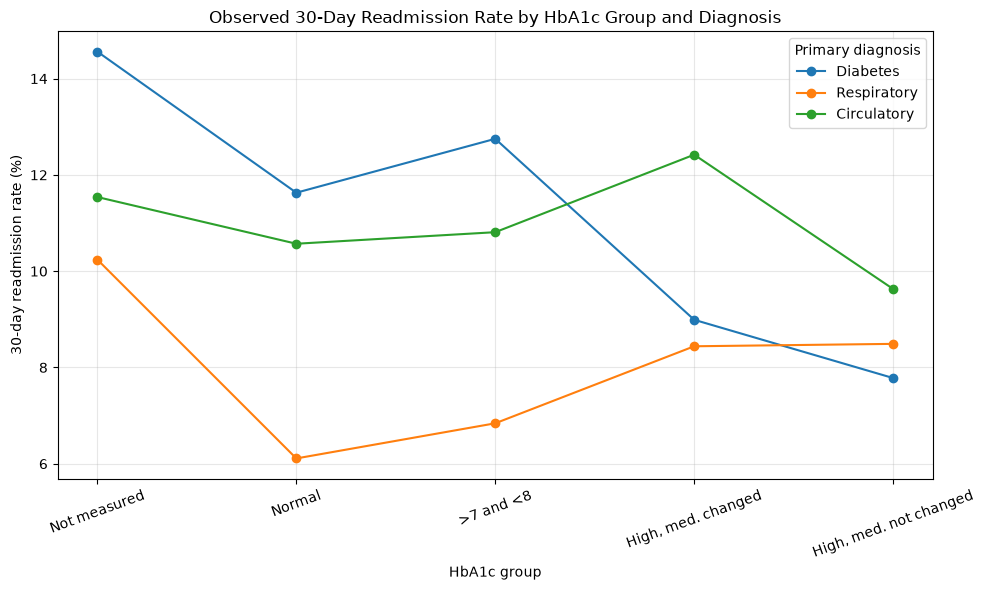

In [58]:
import matplotlib.pyplot as plt

# Set the HbA1c group order.
group_order = [
    "Not measured",
    "Normal",
    ">7 and <8",
    "High, med. changed",
    "High, med. not changed",
]

# Set the diagnosis order.
diagnosis_order = [
    "Diabetes",
    "Respiratory",
    "Circulatory",
]

plot_data = (
    hba1c_diag_rates
    .pivot(
        index="hba1c_group",
        columns="diag_1_category",
        values="readmission_rate",
    )
    .reindex(group_order)
    .reindex(columns=diagnosis_order)
)

# Plot observed readmission rates.
fig, ax = plt.subplots(figsize=(10, 6))

for diagnosis in diagnosis_order:
    ax.plot(
        plot_data.index,
        plot_data[diagnosis],
        marker="o",
        label=diagnosis,
    )

ax.set_xlabel("HbA1c group")
ax.set_ylabel("30-day readmission rate (%)")
ax.set_title("Observed 30-Day Readmission Rate by HbA1c Group and Diagnosis")
ax.legend(title="Primary diagnosis")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [59]:
# Count the medication status categories across all medication columns
medication_columns = [
    column for column in data.columns
    if column not in [
        "encounter_id",
        "patient_nbr",
        "readmitted",
        "readmitted_30d"
    ]
    and column in [
        "metformin", "repaglinide", "nateglinide", "chlorpropamide",
        "glimepiride", "acetohexamide", "glipizide", "glyburide",
        "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
        "miglitol", "troglitazone", "tolazamide", "examide",
        "citoglipton", "insulin", "glyburide-metformin",
        "glipizide-metformin", "glimepiride-pioglitazone",
        "metformin-rosiglitazone", "metformin-pioglitazone"
    ]
]

# Show how often each status appears for every medication
medication_summary = {}

for column in medication_columns:
    medication_summary[column] = data[column].value_counts()

display(pd.DataFrame(medication_summary).fillna(0).astype(int))

,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,...,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone
Down,575,45,11,1,194,0,560,564,0,118,...,0,0,0,0,12218,6,0,0,0,0
No,81778,100227,101063,101680,96575,101765,89080,91116,101743,94438,...,101763,101727,101766,101766,47383,101060,101753,101765,101764,101765
Steady,18346,1384,668,79,4670,1,11356,9274,23,6976,...,3,38,0,0,30849,692,13,1,2,1
Up,1067,110,24,6,327,0,770,812,0,234,...,0,1,0,0,11316,8,0,0,0,0


In [60]:
# Count the main medication status categories
medication_columns = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide",
    "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
    "miglitol", "troglitazone", "tolazamide", "examide",
    "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone"
]

# Print one compact summary per medication
for column in medication_columns:
    counts = data[column].value_counts()
    print(f"\n{column}")
    for status, count in counts.items():
        print(f"  {status}: {count:,}")


metformin
  No: 81,778
  Steady: 18,346
  Up: 1,067
  Down: 575

repaglinide
  No: 100,227
  Steady: 1,384
  Up: 110
  Down: 45

nateglinide
  No: 101,063
  Steady: 668
  Up: 24
  Down: 11

chlorpropamide
  No: 101,680
  Steady: 79
  Up: 6
  Down: 1

glimepiride
  No: 96,575
  Steady: 4,670
  Up: 327
  Down: 194

acetohexamide
  No: 101,765
  Steady: 1

glipizide
  No: 89,080
  Steady: 11,356
  Up: 770
  Down: 560

glyburide
  No: 91,116
  Steady: 9,274
  Up: 812
  Down: 564

tolbutamide
  No: 101,743
  Steady: 23

pioglitazone
  No: 94,438
  Steady: 6,976
  Up: 234
  Down: 118

rosiglitazone
  No: 95,401
  Steady: 6,100
  Up: 178
  Down: 87

acarbose
  No: 101,458
  Steady: 295
  Up: 10
  Down: 3

miglitol
  No: 101,728
  Steady: 31
  Down: 5
  Up: 2

troglitazone
  No: 101,763
  Steady: 3

tolazamide
  No: 101,727
  Steady: 38
  Up: 1

examide
  No: 101,766

citoglipton
  No: 101,766

insulin
  No: 47,383
  Steady: 30,849
  Down: 12,218
  Up: 11,316

glyburide-metformin
  No: 101,06

In [61]:
# Compare medication status with 30-day readmission
for medication in ["metformin", "insulin"]:
    summary = (
        data.groupby(medication)["readmitted_30d"]
        .agg(
            encounters="count",
            readmissions_30d="sum",
            readmission_rate="mean"
        )
        .reset_index()
    )

    # Convert the rate to a percentage
    summary["readmission_rate"] = (
        summary["readmission_rate"] * 100
    ).round(2)

    print(f"\n{medication}")
    print(summary.to_string(index=False))


metformin
metformin  encounters  readmissions_30d  readmission_rate
     Down         575                69             12.00
       No       81778              9418             11.52
   Steady       18346              1782              9.71
       Up        1067                88              8.25

insulin
insulin  encounters  readmissions_30d  readmission_rate
   Down       12218              1698             13.90
     No       47383              4756             10.04
 Steady       30849              3433             11.13
     Up       11316              1470             12.99


In [62]:
# Compare overall medication management with 30-day readmission
for column in ["change", "diabetesMed"]:
    summary = (
        data.groupby(column)["readmitted_30d"]
        .agg(
            encounters="count",
            readmissions_30d="sum",
            readmission_rate="mean"
        )
        .reset_index()
    )

    # Convert the rate to a percentage
    summary["readmission_rate"] = (
        summary["readmission_rate"] * 100
    ).round(2)

    print(f"\n{column}")
    print(summary.to_string(index=False))


change
change  encounters  readmissions_30d  readmission_rate
    Ch       47011              5558             11.82
    No       54755              5799             10.59

diabetesMed
diabetesMed  encounters  readmissions_30d  readmission_rate
         No       23403              2246              9.60
        Yes       78363              9111             11.63


In [63]:
# Summarize the three diagnosis fields
diagnosis_summary = []

for column in ["diag_1", "diag_2", "diag_3"]:
    diagnosis_summary.append({
        "column": column,
        "unique_values": data[column].nunique(dropna=True),
        "missing": ((data[column] == "?") | data[column].isna()).sum(),
        "missing_percent": round(
            (((data[column] == "?") | data[column].isna()).sum()
             / len(data)) * 100,
            2
        )
    })

# Print a clean text summary
for row in diagnosis_summary:
    print(
        f"{row['column']}: "
        f"{row['unique_values']:,} unique values, "
        f"{row['missing']:,} missing "
        f"({row['missing_percent']:.2f}%)"
    )

diag_1: 717 unique values, 21 missing (0.02%)
diag_2: 749 unique values, 358 missing (0.35%)
diag_3: 790 unique values, 1,423 missing (1.40%)


In [64]:
# Compare diagnosis count with 30-day readmission
diagnosis_count_summary = (
    data.groupby("number_diagnoses")["readmitted_30d"]
    .agg(
        encounters="count",
        readmissions_30d="sum",
        readmission_rate="mean"
    )
    .reset_index()
)

# Convert the rate to a percentage
diagnosis_count_summary["readmission_rate"] = (
    diagnosis_count_summary["readmission_rate"] * 100
).round(2)

print(diagnosis_count_summary.to_string(index=False))

 number_diagnoses  encounters  readmissions_30d  readmission_rate
                1         219                13              5.94
                2        1023                62              6.06
                3        2835               209              7.37
                4        5537               457              8.25
                5       11393              1043              9.15
                6       10161              1058             10.41
                7       10393              1119             10.77
                8       10616              1254             11.81
                9       49474              6125             12.38
               10          17                 3             17.65
               11          11                 3             27.27
               12           9                 1             11.11
               13          16                 3             18.75
               14           7                 1             14.29
          

In [65]:
# Summarize prior healthcare utilization
utilization_columns = [
    "number_inpatient",
    "number_outpatient",
    "number_emergency"
]

for column in utilization_columns:
    summary = (
        data.groupby(column)["readmitted_30d"]
        .agg(
            encounters="count",
            readmissions_30d="sum",
            readmission_rate="mean"
        )
        .reset_index()
    )

    # Show only the most common utilization values
    summary = summary.sort_values("encounters", ascending=False).head(10)

    summary["readmission_rate"] = (
        summary["readmission_rate"] * 100
    ).round(2)

    print(f"\n{column}")
    print(summary.to_string(index=False))


number_inpatient
 number_inpatient  encounters  readmissions_30d  readmission_rate
                0       67630              5706              8.44
                1       19521              2523             12.92
                2        7566              1319             17.43
                3        3411               692             20.29
                4        1622               383             23.61
                5         812               255             31.40
                6         480               166             34.58
                7         268                95             35.45
                8         151                67             44.37
                9         111                47             42.34

number_outpatient
 number_outpatient  encounters  readmissions_30d  readmission_rate
                 0       85027              9076             10.67
                 1        8547              1190             13.92
                 2        3594      

In [66]:
# List the dataset columns for prediction-timing review
for number, column in enumerate(data.columns, start=1):
    print(f"{number:02d}. {column}")

01. encounter_id
02. patient_nbr
03. race
04. gender
05. age
06. weight
07. admission_type_id
08. discharge_disposition_id
09. admission_source_id
10. time_in_hospital
11. payer_code
12. medical_specialty
13. num_lab_procedures
14. num_procedures
15. num_medications
16. number_outpatient
17. number_emergency
18. number_inpatient
19. diag_1
20. diag_2
21. diag_3
22. number_diagnoses
23. max_glu_serum
24. A1Cresult
25. metformin
26. repaglinide
27. nateglinide
28. chlorpropamide
29. glimepiride
30. acetohexamide
31. glipizide
32. glyburide
33. tolbutamide
34. pioglitazone
35. rosiglitazone
36. acarbose
37. miglitol
38. troglitazone
39. tolazamide
40. examide
41. citoglipton
42. insulin
43. glyburide-metformin
44. glipizide-metformin
45. glimepiride-pioglitazone
46. metformin-rosiglitazone
47. metformin-pioglitazone
48. change
49. diabetesMed
50. readmitted
51. readmitted_30d
52. admission_type
53. discharge_disposition
54. admission_source
55. diag_1_category
56. hba1c_group


In [67]:
# Select meaningful numeric variables for correlation analysis
correlation_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "readmitted_30d"
]

# Calculate Pearson correlations
correlation_matrix = data[correlation_columns].corr()

# Print the matrix in a readable format
print(correlation_matrix.round(2).to_string())

                    time_in_hospital  num_lab_procedures  num_procedures  num_medications  number_outpatient  number_emergency  number_inpatient  number_diagnoses  readmitted_30d
time_in_hospital                1.00                0.32            0.19             0.47              -0.01             -0.01              0.07              0.22            0.04
num_lab_procedures              0.32                1.00            0.06             0.27              -0.01             -0.00              0.04              0.15            0.02
num_procedures                  0.19                0.06            1.00             0.39              -0.02             -0.04             -0.07              0.07           -0.01
num_medications                 0.47                0.27            0.39             1.00               0.05              0.01              0.06              0.26            0.04
number_outpatient              -0.01               -0.01           -0.02             0.05               1

## Prediction Point

This project defines the prediction point as **hospital discharge**.

The model will use information available by the time the patient is discharged to predict whether the patient will be readmitted within 30 days.

This means:

- Admission variables are available before or at admission.
- Hospital-course variables are available during the stay.
- Discharge variables are available at discharge.
- `readmitted_30d` is the outcome and must never be used as a feature.
- Patient identifiers such as `encounter_id` and `patient_nbr` are identifiers, not predictive measurements.

This prediction point is a project design decision for the portfolio analysis and is not intended to reproduce the methodology of the referenced paper.

In [68]:
# Define columns by when they become available
timing_groups = {
    "identifier": [
        "encounter_id",
        "patient_nbr",
    ],
    "admission": [
        "admission_type_id",
        "admission_source_id",
    ],
    "hospital_course": [
        "time_in_hospital",
        "num_lab_procedures",
        "num_procedures",
        "num_medications",
    ],
    "prior_utilization": [
        "number_outpatient",
        "number_emergency",
        "number_inpatient",
    ],
    "discharge": [
        "discharge_disposition_id",
        "discharge_disposition",
    ],
    "outcome": [
        "readmitted",
        "readmitted_30d",
    ],
}

# Check that every listed column exists
for group, columns in timing_groups.items():
    missing = [column for column in columns if column not in data.columns]
    print(f"{group}: missing columns = {missing}")

identifier: missing columns = []
admission: missing columns = []
hospital_course: missing columns = []
prior_utilization: missing columns = []
discharge: missing columns = []
outcome: missing columns = []


In [69]:
# Identify columns that must never be model features
leakage_columns = [
    "readmitted",
    "readmitted_30d",
]

# Show identifiers separately because they can cause patient-level leakage
identifier_columns = [
    "encounter_id",
    "patient_nbr",
]

print("Outcome columns excluded from features:")
print(leakage_columns)

print("\nIdentifier columns requiring special handling:")
print(identifier_columns)

Outcome columns excluded from features:
['readmitted', 'readmitted_30d']

Identifier columns requiring special handling:
['encounter_id', 'patient_nbr']


In [70]:
# Check how many patients have multiple encounters
patient_counts = data["patient_nbr"].value_counts()

print("Unique patients:", patient_counts.size)
print("Patients with multiple encounters:", (patient_counts > 1).sum())
print("Maximum encounters for one patient:", patient_counts.max())

Unique patients: 71518
Patients with multiple encounters: 16773
Maximum encounters for one patient: 40


In [71]:
# Compare patients with one vs multiple encounters
patient_summary = (
    data.groupby("patient_nbr")
    .agg(
        encounters=("encounter_id", "size"),
        readmission_rate_30d=("readmitted_30d", "mean")
    )
)

patient_summary["multiple_encounters"] = (
    patient_summary["encounters"] > 1
)

# Summarize the two patient groups
comparison = (
    patient_summary
    .groupby("multiple_encounters")
    [["encounters", "readmission_rate_30d"]]
    .agg(["count", "mean"])
)

display(comparison)

encounters           readmission_rate_30d          
                         count      mean                count      mean
multiple_encounters                                                    
False                    54745  1.000000                54745  0.039565
True                     16773  2.803374                16773  0.174123

In [72]:
# Check target rates across identifier ranges
data["encounter_id_group"] = pd.qcut(
    data["encounter_id"],
    q=10,
    duplicates="drop"
)

identifier_target_check = (
    data.groupby("encounter_id_group", observed=True)["readmitted_30d"]
    .agg(
        encounters="count",
        readmission_rate="mean"
    )
    .reset_index()
)

identifier_target_check["readmission_rate"] = (
    identifier_target_check["readmission_rate"] * 100
).round(2)

display(identifier_target_check)

,encounter_id_group,encounters,readmission_rate
0,"(12521.999, 43368426.0]",10177,10.92
1,"(43368426.0, 71757270.0]",10177,12.01
2,"(71757270.0, 98704311.0]",10176,11.77
3,"(98704311.0, 126324102.0]",10177,10.77
4,"(126324102.0, 152388987.0]",10176,11.94
5,"(152388987.0, 170676276.0]",10177,11.18
6,"(170676276.0, 205984164.0]",10176,10.83
7,"(205984164.0, 252308694.0]",10177,10.89
8,"(252308694.0, 311346359.0]",10176,10.69
9,"(311346359.0, 443867222.0]",10177,10.60


In [73]:
# Remove temporary EDA column
data.drop(columns=["encounter_id_group"], inplace=True)

In [74]:
# Check readmission rates across patient ID groups
data["patient_id_group"] = pd.qcut(
    data["patient_nbr"],
    q=10,
    duplicates="drop"
)

patient_id_check = (
    data.groupby("patient_id_group", observed=True)["readmitted_30d"]
    .agg(
        encounters="count",
        readmission_rate="mean"
    )
    .reset_index()
)

patient_id_check["readmission_rate"] = (
    patient_id_check["readmission_rate"] * 100
).round(2)

display(patient_id_check)

,patient_id_group,encounters,readmission_rate
0,"(134.999, 3957115.5]",10177,10.79
1,"(3957115.5, 18850995.0]",10177,10.61
2,"(18850995.0, 24496155.0]",10178,10.40
3,"(24496155.0, 38854530.0]",10175,9.16
4,"(38854530.0, 45505143.0]",10177,13.75
5,"(45505143.0, 63507825.0]",10177,10.40
6,"(63507825.0, 84417003.0]",10175,11.64
7,"(84417003.0, 91581660.0]",10178,12.90
8,"(91581660.0, 103287825.0]",10175,11.69
9,"(103287825.0, 189502619.0]",10177,10.27


In [75]:
# Remove temporary EDA column
data.drop(columns=["patient_id_group"], inplace=True)

In [76]:
# List variables that are available at discharge
discharge_available = [
    "admission_type_id",
    "admission_source_id",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "diag_1",
    "diag_2",
    "diag_3",
    "number_diagnoses",
    "max_glu_serum",
    "A1Cresult",
    "change",
    "diabetesMed",
    "discharge_disposition_id",
]

# Columns that must never enter the feature set
excluded_columns = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "readmitted_30d",
]

print("Potential model features:")
print(discharge_available)

print("\nExcluded from model features:")
print(excluded_columns)

Potential model features:
['admission_type_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed', 'discharge_disposition_id']

Excluded from model features:
['encounter_id', 'patient_nbr', 'readmitted', 'readmitted_30d']


In [77]:
# Collect all columns already classified
classified_columns = set(
    discharge_available
    + excluded_columns
)

# Find columns that still need a role assigned
unclassified_columns = [
    column
    for column in data.columns
    if column not in classified_columns
]

print("Unclassified columns:")
print(unclassified_columns)

Unclassified columns:
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'admission_type', 'discharge_disposition', 'admission_source', 'diag_1_category', 'hba1c_group']


In [78]:
# Group the remaining raw variables by their role
remaining_taxonomy = {
    "demographics": [
        "race",
        "gender",
        "age",
        "weight",
    ],
    "administrative": [
        "payer_code",
        "medical_specialty",
    ],
    "medications": [
        "metformin",
        "repaglinide",
        "nateglinide",
        "chlorpropamide",
        "glimepiride",
        "acetohexamide",
        "glipizide",
        "glyburide",
        "tolbutamide",
        "pioglitazone",
        "rosiglitazone",
        "acarbose",
        "miglitol",
        "troglitazone",
        "tolazamide",
        "examide",
        "citoglipton",
        "insulin",
        "glyburide-metformin",
        "glipizide-metformin",
        "glimepiride-pioglitazone",
        "metformin-rosiglitazone",
        "metformin-pioglitazone",
    ],
}

# Show the completed groups
for group, columns in remaining_taxonomy.items():
    print(f"\n{group}:")
    print(columns)


demographics:
['race', 'gender', 'age', 'weight']

administrative:
['payer_code', 'medical_specialty']

medications:
['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


In [79]:
# Combine all classification groups
all_taxonomy_groups = {
    **timing_groups,
    **remaining_taxonomy,
}

# Collect every classified column
classified_columns = set()

for columns in all_taxonomy_groups.values():
    classified_columns.update(columns)

# Add derived analysis columns
classified_columns.update([
    "admission_type",
    "discharge_disposition",
    "admission_source",
    "diag_1_category",
])

# Check for columns without a classification
unclassified = [
    column
    for column in data.columns
    if column not in classified_columns
]

print("Total dataset columns:", len(data.columns))
print("Classified columns:", len(classified_columns))
print("Unclassified columns:", unclassified)

Total dataset columns: 56
Classified columns: 47
Unclassified columns: ['diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed', 'hba1c_group']


In [80]:
# Add the remaining clinical variables
remaining_taxonomy.update({
    "diagnoses": [
        "diag_1",
        "diag_2",
        "diag_3",
        "number_diagnoses",
    ],
    "laboratory": [
        "max_glu_serum",
        "A1Cresult",
    ],
    "medication_management": [
        "change",
        "diabetesMed",
    ],
})

In [81]:
# Combine all classification groups
all_taxonomy_groups = {
    **timing_groups,
    **remaining_taxonomy,
}

# Collect every classified column
classified_columns = set()

for columns in all_taxonomy_groups.values():
    classified_columns.update(columns)

# Add derived analysis columns
classified_columns.update([
    "admission_type",
    "discharge_disposition",
    "admission_source",
    "diag_1_category",
])

# Check for columns without a classification
unclassified = [
    column
    for column in data.columns
    if column not in classified_columns
]

print("Total dataset columns:", len(data.columns))
print("Classified columns:", len(classified_columns))
print("Unclassified columns:", unclassified)

Total dataset columns: 56
Classified columns: 55
Unclassified columns: ['hba1c_group']


In [82]:
# Verify the original outcome and binary target
target_check = (
    data.groupby(["readmitted", "readmitted_30d"])
    .size()
    .reset_index(name="encounters")
)

display(target_check)

,readmitted,readmitted_30d,encounters
0,<30,1,11357
1,>30,0,35545
2,NO,0,54864


In [83]:
# Build the candidate feature list from the taxonomy
candidate_features = []

for group, columns in all_taxonomy_groups.items():
    if group != "identifier" and group != "outcome":
        candidate_features.extend(columns)

# Remove duplicates while preserving order
candidate_features = list(dict.fromkeys(candidate_features))

print("Number of candidate features:", len(candidate_features))
print("\nCandidate features:")
print(candidate_features)

Number of candidate features: 48

Candidate features:
['admission_type_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'discharge_disposition_id', 'discharge_disposition', 'race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed']


In [84]:
# Check that no outcome or identifier enters the candidate feature set
forbidden_features = {
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "readmitted_30d",
}

leakage_check = [
    feature
    for feature in candidate_features
    if feature in forbidden_features
]

print("Forbidden features found:", leakage_check)
print("Leakage audit passed:", len(leakage_check) == 0)

Forbidden features found: []
Leakage audit passed: True


In [85]:
# Create the modeling dataset
model_data = data[candidate_features + ["readmitted_30d"]].copy()

# Verify the modeling boundary
print("Modeling dataset shape:", model_data.shape)
print("Target included:", "readmitted_30d" in model_data.columns)
print("Identifiers included:", any(
    column in model_data.columns
    for column in ["encounter_id", "patient_nbr"]
))

Modeling dataset shape: (101766, 49)
Target included: True
Identifiers included: False


In [86]:
# Inspect feature data types
model_data.dtypes.value_counts()

str      37
int64    12
Name: count, dtype: int64

In [87]:
# List integer columns before preprocessing
integer_features = [
    column
    for column in model_data.columns
    if model_data[column].dtype == "int64"
]

print(integer_features)

['admission_type_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'discharge_disposition_id', 'number_diagnoses', 'readmitted_30d']


In [88]:
# Separate true numeric features from categorical ID codes
numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

categorical_code_features = [
    "admission_type_id",
    "admission_source_id",
    "discharge_disposition_id",
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical code features:")
print(categorical_code_features)

Numeric features:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical code features:
['admission_type_id', 'admission_source_id', 'discharge_disposition_id']


In [89]:
# Check the decoded categorical feature values
decoded_features = [
    "admission_type",
    "admission_source",
    "discharge_disposition",
]

for column in decoded_features:
    print(f"\n{column}:")
    print(data[column].value_counts(dropna=False).to_string())


admission_type:
admission_type
Emergency        53990
Elective         18869
Urgent           18480
NaN               5291
Not Available     4785
Not Mapped         320
Trauma Center       21
Newborn             10

admission_source:
admission_source
 Emergency Room                                               57494
 Physician Referral                                           29565
NaN                                                            6781
Transfer from a hospital                                       3187
 Transfer from another health care facility                    2264
Clinic Referral                                                1104
 Transfer from a Skilled Nursing Facility (SNF)                 855
HMO Referral                                                    187
 Not Mapped                                                     161
 Not Available                                                  125
 Court/Law Enforcement                                           16


In [90]:
# Count rare categories in each decoded feature
for column in decoded_features:
    counts = data[column].value_counts(dropna=False)
    rare = counts[counts < 100]

    print(f"\n{column}")
    print("Categories with fewer than 100 encounters:", len(rare))
    print(rare.to_string())


admission_type
Categories with fewer than 100 encounters: 2
admission_type
Trauma Center    21
Newborn          10

admission_source
Categories with fewer than 100 encounters: 7
admission_source
 Court/Law Enforcement                                        16
 Transfer from hospital inpt/same fac reslt in a sep claim    12
 Transfer from critial access hospital                         8
 Extramural Birth                                              2
Normal Delivery                                                2
 Transfer from Ambulatory Surgery Center                       2
 Sick Baby                                                     1

discharge_disposition
Categories with fewer than 100 encounters: 10
discharge_disposition
Discharged/transferred within this institution to Medicare approved swing bed                              63
Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.    48
Admitted as an inpatient to this hospi

In [91]:
# List categorical features and their number of unique values
categorical_features = [
    column
    for column in model_data.columns
    if model_data[column].dtype == "str"
]

categorical_cardinality = (
    model_data[categorical_features]
    .nunique(dropna=False)
    .sort_values(ascending=False)
)

display(categorical_cardinality)

diag_3                      790
diag_2                      749
diag_1                      717
medical_specialty            73
discharge_disposition        26
payer_code                   18
weight                       10
age                          10
race                          6
max_glu_serum                 4
nateglinide                   4
metformin                     4
repaglinide                   4
miglitol                      4
glyburide                     4
pioglitazone                  4
rosiglitazone                 4
acarbose                      4
chlorpropamide                4
glimepiride                   4
glipizide                     4
A1Cresult                     4
glyburide-metformin           4
insulin                       4
gender                        3
tolazamide                    3
troglitazone                  2
acetohexamide                 2
tolbutamide                   2
glipizide-metformin           2
metformin-pioglitazone        2
metformi

In [92]:
# List categorical features and their number of unique values
categorical_features = [
    column
    for column in model_data.columns
    if model_data[column].dtype == "str"
]

categorical_cardinality = (
    model_data[categorical_features]
    .nunique(dropna=False)
    .sort_values(ascending=False)
)

display(categorical_cardinality)

diag_3                      790
diag_2                      749
diag_1                      717
medical_specialty            73
discharge_disposition        26
payer_code                   18
weight                       10
age                          10
race                          6
max_glu_serum                 4
nateglinide                   4
metformin                     4
repaglinide                   4
miglitol                      4
glyburide                     4
pioglitazone                  4
rosiglitazone                 4
acarbose                      4
chlorpropamide                4
glimepiride                   4
glipizide                     4
A1Cresult                     4
glyburide-metformin           4
insulin                       4
gender                        3
tolazamide                    3
troglitazone                  2
acetohexamide                 2
tolbutamide                   2
glipizide-metformin           2
metformin-pioglitazone        2
metformi

In [93]:
# Define the baseline feature groups.
numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

demographic_features = [
    "race",
    "gender",
    "age",
    "weight",
]

admission_features = [
    "admission_type",
    "admission_source",
]


diagnosis_features = [
    "diag_1",
    "diag_2",
    "diag_3",
]

laboratory_features = [
    "max_glu_serum",
    "A1Cresult",
]

medication_features = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",
]

medication_management_features = [
    "change",
    "diabetesMed",
]

administrative_features = [
    "payer_code",
    "medical_specialty",
]

discharge_features = [
    "discharge_disposition",
]

candidate_features = (
    numeric_features
    + demographic_features
    + admission_features
    + diagnosis_features
    + laboratory_features
    + medication_features
    + medication_management_features
    + administrative_features
    + discharge_features
)

# Check for duplicate features.
duplicate_features = sorted({
    feature
    for feature in candidate_features
    if candidate_features.count(feature) > 1
})

print("Candidate feature count:", len(candidate_features))
print("Unique feature count:", len(set(candidate_features)))
print("Duplicate features:", duplicate_features)

# Check that every feature exists in the dataframe.
missing_features = [
    feature for feature in candidate_features
    if feature not in data.columns
]

print("Missing features:", missing_features)

Candidate feature count: 47
Unique feature count: 47
Duplicate features: []
Missing features: []
